# Notebook 05a — Delta Signal Analysis

Compares three delta variants as MIA signals on the target model.
Outputs saved to `logs/05a_target_deltas.npz` for use by NB05b.

In [1]:
%load_ext autoreload
%autoreload 2


In [ ]:
import sys
sys.path.insert(0, '..')

import json, time, logging
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from sklearn.metrics import roc_curve, auc as sk_auc, confusion_matrix, ConfusionMatrixDisplay

from src.data.auth_dataset   import load_auth_dataset, normalize_auth
from src.models.gait_cnn    import GaitCNN
from src.models.auth_model  import AuthModel
from src.attacks.lira_shadow import ShadowLSTM, compute_subject_scores, all_deltas
from src.utils.latex_writer  import write_latex_metrics

DATA_ROOT  = Path('../data')
LOG_DIR    = Path('../logs')
CKPT_DIR   = Path('../checkpoints')
RESULT_DIR = Path('../results')
BATCH      = 512
DEVICE     = torch.device('cpu')

log = logging.getLogger('nb05a')
log.setLevel(logging.DEBUG)
log.handlers.clear()
fh = logging.FileHandler(LOG_DIR / '05a_delta_analysis.log', mode='w')
fh.setFormatter(logging.Formatter('%(asctime)s  %(message)s', datefmt='%H:%M:%S'))
sh = logging.StreamHandler()
sh.setFormatter(logging.Formatter('%(message)s'))
log.addHandler(fh); log.addHandler(sh)
log.info('=== Notebook 05a — Delta Signal Analysis ===')
# ── dataset config ──
import sys as _sys; _sys.path.insert(0, '..')
from src.utils.config_loader import get_dataset, dataset_dirs, dataset_files
from src.data.pairs_loader   import load_auth_pairs, load_attribution, build_pair_subjects_train, build_pair_subjects_test

DATASET = 'whuGAIT'  # <<< RUNNER INJECTS THIS
# Per-dataset subdirectories — isolates all artifacts by dataset
_ds_dirs   = dataset_dirs(Path('../logs'), Path('../checkpoints'), artifacts_base=Path('../artifacts'), results_base=Path('../results'), dataset=DATASET)
LOG_DIR    = _ds_dirs['logs']
ARTIFACT_DIR = _ds_dirs['artifacts']
CKPT_DIR   = _ds_dirs['checkpoints']
RESULT_DIR = _ds_dirs['results']
PATHS   = dataset_files(LOG_DIR, CKPT_DIR, artifacts_dir=ARTIFACT_DIR)

with open(PATHS['split_json']) as _f:
    _split = json.load(_f)
member_ids    = _split['train_ids']
nonmember_ids = _split['held_out_ids']
N_CLASSES     = len(member_ids)
member_id_set    = set(member_ids)
nonmember_id_set = set(nonmember_ids)
log.info(f'Dataset: {DATASET}  |  N_CLASSES: {N_CLASSES}')


## Section 1 — Simple Delta (baseline)

The raw delta δ(s) = mean P(different | impostor pairs) − mean P(different | genuine pairs) from NB04.

In [ ]:
nb04 = np.load(ARTIFACT_DIR / '04_mia_scores.npz')
member_ids       = nb04['member_ids']
member_deltas    = nb04['member_scores']
nonmember_ids    = nb04['nonmember_ids']
nonmember_deltas = nb04['nonmember_scores']

all_scores = np.concatenate([member_deltas, nonmember_deltas])
all_labels = np.concatenate([np.ones(len(member_deltas)), np.zeros(len(nonmember_deltas))])

fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
mia_auc  = sk_auc(fpr, tpr)
youden_j = tpr - fpr
opt_idx  = int(np.argmax(youden_j))
opt_thr, opt_tpr, opt_fpr = float(thresholds[opt_idx]), float(tpr[opt_idx]), float(fpr[opt_idx])

def tpr_at_fpr(fpr_arr, tpr_arr, target):
    idx = np.searchsorted(fpr_arr, target, side='right') - 1
    return float(tpr_arr[max(0, idx)])

tpr_at_10 = tpr_at_fpr(fpr, tpr, 0.10)
tpr_at_20 = tpr_at_fpr(fpr, tpr, 0.20)

log.info(f'Simple delta  AUC={mia_auc:.4f}  Youden: TPR={opt_tpr:.3f} FPR={opt_fpr:.3f}  TPR@0.10={tpr_at_10:.3f}')
print(f'Members ({len(member_deltas)}):     Δ mean={member_deltas.mean():.4f}  std={member_deltas.std():.4f}')
print(f'Non-members ({len(nonmember_deltas)}): Δ mean={nonmember_deltas.mean():.4f}  std={nonmember_deltas.std():.4f}')
print(f'Delta gap: {member_deltas.mean() - nonmember_deltas.mean():.4f}')
print(f'AUC={mia_auc:.4f}  Youden: TPR={opt_tpr:.3f} @ FPR={opt_fpr:.3f}  TPR@FPR=0.10: {tpr_at_10:.3f}')


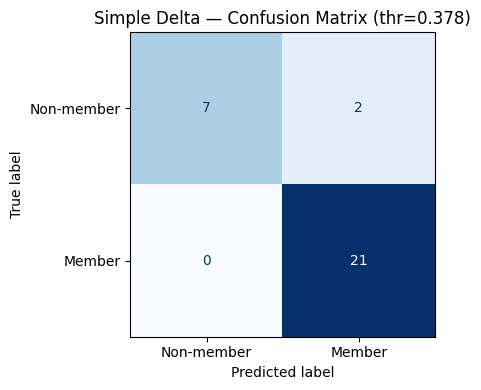

TN=7  FP=2  FN=0  TP=21  Prec=0.913  Rec=1.000  F1=0.955


In [4]:
preds = (all_scores >= opt_thr).astype(int)
cm    = confusion_matrix(all_labels.astype(int), preds)
tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
precision = tp / (fp + tp) if (fp + tp) > 0 else 0.0
recall    = tp / (fn + tp) if (fn + tp) > 0 else 0.0
f1        = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0.0

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Non-member', 'Member']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Simple Delta — Confusion Matrix (thr={opt_thr:.3f})')
plt.tight_layout()
plt.savefig(RESULT_DIR / '05a_confusion_matrix.png', dpi=150)
plt.show()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}  Prec={precision:.3f}  Rec={recall:.3f}  F1={f1:.3f}')

## Section 2 — Model and Feature Setup

Load the target model and precompute CNN feature maps for all D5 pairs.
This is the fixed representation the shadow LSTMs operate on.

In [5]:
norm_data = np.load(PATHS['norm_stats'])
norm_mean2, norm_std2 = norm_data['mean'], norm_data['std']


# Load frozen CNN + target auth model
_cnn_n = json.load(open(PATHS['cnn_meta']))['n_classes'] if PATHS['cnn_meta'].exists() else N_CLASSES
cnn_base = GaitCNN(n_classes=_cnn_n)
cnn_base.load_state_dict(torch.load(PATHS['cnn_ckpt'], map_location='cpu'))
cnn_base.eval()

target_auth = AuthModel(cnn_base).to(DEVICE)
target_auth.load_state_dict(torch.load(PATHS['auth_ckpt'], map_location='cpu'))
target_auth.eval()

# Train pairs (members)
X1_tr, X2_tr, y_tr = load_auth_pairs('train', DATA_ROOT, ARTIFACT_DIR)
X1_n, X2_n, _      = normalize_auth(X1_tr, X2_tr, (norm_mean2, norm_std2))

print('Precomputing CNN features for D5 train...')
feats_list = []
with torch.no_grad():
    for s in range(0, len(X1_n), BATCH):
        e = min(s + BATCH, len(X1_n))
        f1 = cnn_base.get_feature_maps(torch.from_numpy(X1_n[s:e]).float())
        f2 = cnn_base.get_feature_maps(torch.from_numpy(X2_n[s:e]).float())
        feats_list.append(torch.cat([f1, f2], dim=1).half().cpu())
all_feats = torch.cat(feats_list, dim=0)
print(f'Train features: shape={tuple(all_feats.shape)}  mem={all_feats.nbytes/1e6:.0f} MB')

# Test pairs (non-members)
X1_te, X2_te, y_te = load_auth_pairs('test', DATA_ROOT, ARTIFACT_DIR)
X1_te_n, X2_te_n, _ = normalize_auth(X1_te, X2_te, (norm_mean2, norm_std2))

print('Precomputing CNN features for D5 test...')
te_feats_list = []
with torch.no_grad():
    for s in range(0, len(X1_te_n), BATCH):
        e = min(s + BATCH, len(X1_te_n))
        f1 = cnn_base.get_feature_maps(torch.from_numpy(X1_te_n[s:e]).float())
        f2 = cnn_base.get_feature_maps(torch.from_numpy(X2_te_n[s:e]).float())
        te_feats_list.append(torch.cat([f1, f2], dim=1).half().cpu())
te_feats = torch.cat(te_feats_list, dim=0)
print(f'Test  features: shape={tuple(te_feats.shape)}')

# Pair attribution
subj_win1_tr, subj_win2_tr = load_attribution('train', ARTIFACT_DIR)
subj_win1_te, subj_win2_te = load_attribution('test',  ARTIFACT_DIR)
pair_subjects    = build_pair_subjects_train(y_tr, subj_win1_tr, subj_win2_tr, member_id_set, logs_dir=LOG_DIR)
te_pair_subjects = build_pair_subjects_test( y_te, subj_win1_te, subj_win2_te, nonmember_id_set, logs_dir=LOG_DIR)
print(f'Attributed: train={(pair_subjects != -1).sum():,}/{len(y_tr):,}  test={(te_pair_subjects != -1).sum():,}/{len(y_te):,}')

Precomputing CNN features for D5 train...
Train features: shape=(60000, 32, 128)  mem=492 MB
Precomputing CNN features for D5 test...
Test  features: shape=(10000, 32, 128)
Attributed: train=60,000/60,000  test=10,000/10,000


## Section 3 — Three Delta Variants

For each subject we compute a **delta score** summarising how the model distinguishes
their impostor from their genuine pairs. Three formulations:

| Variant | Formula | Note |
|---|---|---|
| **raw** | mean P(different \| y=1) − mean P(different \| y=0) | No transform — current baseline |
| **logit-first** | mean logit(P(different \| y=1)) − mean logit(P(different \| y=0)) | Logit per pair, then mean — faithful to LiRA paper |
| **mean-first** | logit(mean P(different \| y=1)) − logit(mean P(different \| y=0)) | Mean first, then logit |

`logit-first` is the theoretically correct adaptation (LiRA §3, Eq. 2).
`mean-first` aggregates before transforming (Jensen's inequality → different value).


In [6]:
# Wrap target LSTM weights in a ShadowLSTM so we can reuse compute_subject_scores
target_shadow = ShadowLSTM()
target_shadow.lstm.load_state_dict(target_auth.lstm.state_dict())
target_shadow.fc.load_state_dict(target_auth.fc.state_dict())
target_shadow.eval()

target_raw_dict = {int(i): float(d) for i, d in zip(nb04['member_ids'], nb04['member_scores'])}
target_lf_dict  = {}
target_mf_dict  = {}

for mid in target_raw_dict:
    same_sc, diff_sc = compute_subject_scores(target_shadow, all_feats, y_tr, pair_subjects == mid)
    _, lf, mf = all_deltas(same_sc, diff_sc)
    if lf is not None:
        target_lf_dict[mid] = lf
        target_mf_dict[mid] = mf

nm_raw_dict = {int(i): float(d) for i, d in zip(nb04['nonmember_ids'], nb04['nonmember_scores'])}
nm_lf_dict  = {}
nm_mf_dict  = {}

for sid in nm_raw_dict:
    same_sc, diff_sc = compute_subject_scores(target_shadow, te_feats, y_te, te_pair_subjects == sid)
    _, lf, mf = all_deltas(same_sc, diff_sc)
    if lf is not None:
        nm_lf_dict[sid] = lf
        nm_mf_dict[sid] = mf

all_raw_targets = {**target_raw_dict, **nm_raw_dict}
all_lf_targets  = {**target_lf_dict,  **nm_lf_dict}
all_mf_targets  = {**target_mf_dict,  **nm_mf_dict}

member_list    = list(target_raw_dict.keys())
nonmember_list = list(nm_raw_dict.keys())

print(f'Member target deltas   raw={np.mean(list(target_raw_dict.values())):.4f}  lf={np.mean(list(target_lf_dict.values())):.4f}  mf={np.mean(list(target_mf_dict.values())):.4f}')
print(f'Non-member target deltas raw={np.mean(list(nm_raw_dict.values())):.4f}  lf={np.mean(list(nm_lf_dict.values())):.4f}  mf={np.mean(list(nm_mf_dict.values())):.4f}')

Member target deltas   raw=0.5392  lf=3.8422  mf=2.4981
Non-member target deltas raw=0.2601  lf=1.8547  mf=1.1532


## Section 4 — ROC Comparison

Variant              AUC   TPR@0.10   TPR@0.20
----------------------------------------------
raw (NB04)        0.9153  0.476      0.762
logit-first       0.9259  0.524      0.810
mean-first        0.9101  0.476      0.714


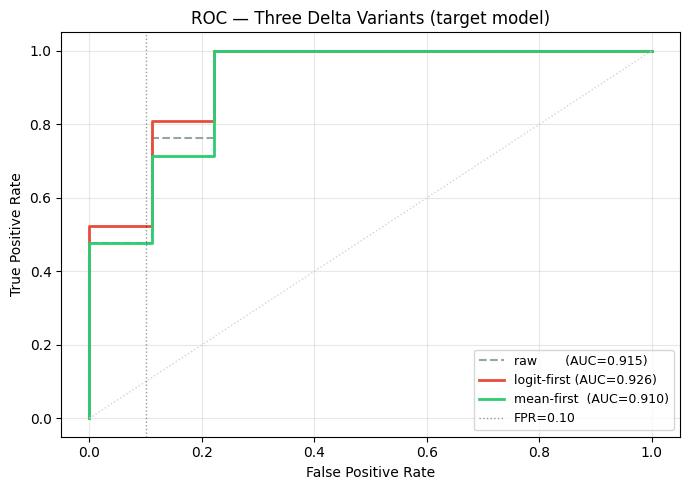

Delta variants: raw=0.9153  lf=0.9259  mf=0.9101


In [7]:
def variant_roc(target_dict, m_list, nm_list):
    sids, scores, labels = [], [], []
    for sid in m_list:
        if sid in target_dict:
            sids.append(sid); scores.append(target_dict[sid]); labels.append(1)
    for sid in nm_list:
        if sid in target_dict:
            sids.append(sid); scores.append(target_dict[sid]); labels.append(0)
    fpr_v, tpr_v, _ = roc_curve(np.array(labels), np.array(scores))
    return fpr_v, tpr_v, sk_auc(fpr_v, tpr_v)

fpr_lf, tpr_lf, auc_lf = variant_roc(all_lf_targets, member_list, nonmember_list)
fpr_mf, tpr_mf, auc_mf = variant_roc(all_mf_targets, member_list, nonmember_list)

print(f'{"Variant":<16}  {"AUC":>6}  {"TPR@0.10":>9}  {"TPR@0.20":>9}')
print('-' * 46)
for name, fpr_v, tpr_v, auc_v in [
    ('raw (NB04)',    fpr,    tpr,    mia_auc),
    ('logit-first',  fpr_lf, tpr_lf, auc_lf),
    ('mean-first',   fpr_mf, tpr_mf, auc_mf),
]:
    print(f'{name:<16}  {auc_v:.4f}  {tpr_at_fpr(fpr_v, tpr_v, 0.10):.3f}      {tpr_at_fpr(fpr_v, tpr_v, 0.20):.3f}')

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr,    tpr,    color='#95a5a6', linewidth=1.5, linestyle='--', label=f'raw       (AUC={mia_auc:.3f})')
ax.plot(fpr_lf, tpr_lf, color='#e74c3c', linewidth=2,                   label=f'logit-first (AUC={auc_lf:.3f})')
ax.plot(fpr_mf, tpr_mf, color='#2ecc71', linewidth=2,                   label=f'mean-first  (AUC={auc_mf:.3f})')
ax.plot([0,1],[0,1], color='lightgray', linestyle=':', linewidth=1)
ax.axvline(0.10, color='black', linestyle=':', linewidth=1, alpha=0.4, label='FPR=0.10')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC — Three Delta Variants (target model)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / '05a_delta_roc.png', dpi=150)
plt.show()
log.info(f'Delta variants: raw={mia_auc:.4f}  lf={auc_lf:.4f}  mf={auc_mf:.4f}')

## Section 5 — Save & Export

In [ ]:
# Save all target delta dicts for NB05b
np.savez(
    ARTIFACT_DIR / '05a_target_deltas.npz',
    member_ids=np.array(member_list),
    nonmember_ids=np.array(nonmember_list),
    member_raw=np.array([target_raw_dict[s] for s in member_list]),
    member_lf=np.array([target_lf_dict.get(s, np.nan) for s in member_list]),
    member_mf=np.array([target_mf_dict.get(s, np.nan) for s in member_list]),
    nonmember_raw=np.array([nm_raw_dict[s] for s in nonmember_list]),
    nonmember_lf=np.array([nm_lf_dict.get(s, np.nan) for s in nonmember_list]),
    nonmember_mf=np.array([nm_mf_dict.get(s, np.nan) for s in nonmember_list]),
)
print(f'Saved: {ARTIFACT_DIR}/05a_target_deltas.npz')

_ds_sfx = '' if DATASET == 'whuGAIT' else f'_{DATASET.lower()}'
_pfx    = '' if DATASET == 'whuGAIT' else DATASET.lower()
write_latex_metrics(f'nb05a{_ds_sfx}', {
    'miaAUC':      f'{mia_auc:.4f}',
    'miaOptThr':   f'{opt_thr:.4f}',
    'miaOptTPR':   f'{opt_tpr:.3f}',
    'miaOptFPR':   f'{opt_fpr:.3f}',
    'miaTPRat10':  f'{tpr_at_10:.3f}',
    'miaTPRat20':  f'{tpr_at_20:.3f}',
    'miaLFauc':    f'{auc_lf:.4f}',
    'miaMFauc':    f'{auc_mf:.4f}',
    'miaMemberN':     int(len(member_list)),
    'miaNonMemberN':  int(len(nonmember_list)),
}, output_dir='../latex/generated', log=log, key_prefix=_pfx)
print('LaTeX macros written.')